# Sprint 2/3 – Treinamento de Modelos de Alta Performance

**Classes:** Cercospora | Healthy | Leaf_rust | Miner | Phoma  
**Dataset:** 50.000 imagens balanceadas (10.000/classe)  
**Meta:** ≥ 85% de acurácia

**Arquiteturas:** EfficientNetB0, EfficientNetB1, MobileNetV3, Custom CNN-SE  
**Técnicas:** MixUp, CutMix, Label Smoothing, Fine-Tuning, Ensemble, Grad-CAM

## Célula 1 – GPU Setup (Execute PRIMEIRO)

In [1]:
# Configurar LD_LIBRARY_PATH ANTES de importar TensorFlow
import os, glob

nvidia_libs = glob.glob(os.path.expanduser('~/.local/lib/python*/site-packages/nvidia/*/lib'))
if nvidia_libs:
    ld = ':'.join(nvidia_libs)
    os.environ['LD_LIBRARY_PATH'] = ld + ':' + os.environ.get('LD_LIBRARY_PATH', '')
    print(f'✓ {len(nvidia_libs)} diretórios NVIDIA no LD_LIBRARY_PATH')
else:
    print('⚠ Bibliotecas NVIDIA não encontradas')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

✓ 11 diretórios NVIDIA no LD_LIBRARY_PATH


## Célula 2 – Instalar Dependências

In [2]:
import subprocess, sys

pkgs = ['tensorflow>=2.15.0', 'keras>=3.0.0', 'matplotlib', 'numpy',
        'pandas', 'scikit-learn', 'seaborn', 'pillow', 'tqdm', 'kagglehub']

print('Instalando dependências...')
for pkg in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg,
                    '--break-system-packages', '-q'], capture_output=True)
print('✓ Dependências instaladas!')

Instalando dependências...
✓ Dependências instaladas!


## Célula 3 – Imports e Verificação de GPU

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, warnings
from pathlib import Path
from datetime import datetime
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, callbacks
from tensorflow.keras.applications import (
    EfficientNetB0, EfficientNetB1, EfficientNetB2, EfficientNetB3, MobileNetV3Large
)

print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    details = tf.config.experimental.get_device_details(gpus[0])
    print(f'\n✅ GPU detectada: {details.get("device_name", gpus[0].name)}')
else:
    print('\n⚠ Nenhuma GPU. Rode ./start_jupyter_gpu.sh para ativar a GPU.')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

I0000 00:00:1773252116.687285   45899 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773252117.311665   45899 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow : 2.21.0
Keras      : 3.13.2

✅ GPU detectada: NVIDIA RTX 4000 Ada Generation


## Célula 4 – Configurações

In [4]:
# Paths
DATASET_DIR  = Path.home() / 'datasets' / 'coffee_balanced_sprint2'
NOTEBOOK_DIR = Path(os.path.abspath(''))
OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs'
MODELS_DIR   = NOTEBOOK_DIR / 'models'
OUTPUT_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

# Classes
CLASS_NAMES = ['Cercospora', 'Healthy', 'Leaf_rust', 'Miner', 'Phoma']
NUM_CLASSES = len(CLASS_NAMES)

# Hiperparâmetros
IMG_SIZE         = 224
BATCH_SIZE       = 32
EPOCHS           = 50
LEARNING_RATE    = 1e-3
VALIDATION_SPLIT = 0.2
TEST_SPLIT       = 0.1
MIXUP_ALPHA      = 0.2
CUTMIX_ALPHA     = 1.0
LABEL_SMOOTHING  = 0.1

print(f'Dataset  : {DATASET_DIR}')
print(f'Outputs  : {OUTPUT_DIR}')
print(f'Img size : {IMG_SIZE}x{IMG_SIZE}  |  Batch: {BATCH_SIZE}  |  Epochs: {EPOCHS}')

Dataset  : /home/t21-g112/datasets/coffee_balanced_sprint2
Outputs  : /home/t21-g112/Desktop/2025-2A-T21-G112-INTERNO/Modulo XV/notebooks/sprint-2/outputs
Img size : 224x224  |  Batch: 32  |  Epochs: 50


## Célula 5 – Preparar Dataset Balanceado

In [5]:
import shutil
from PIL import Image, ImageEnhance, ImageFilter

if DATASET_DIR.exists():
    print(f'✓ Dataset balanceado já existe: {DATASET_DIR}')
    for cls in CLASS_NAMES:
        n = len(list((DATASET_DIR / cls).glob('*.*')))
        print(f'  {cls}: {n:,} imagens')
else:
    print('Dataset não encontrado. Criando automaticamente...\n')
    import kagglehub
    raw = Path(kagglehub.dataset_download('noamaanabdulazeem/jmuben-coffee-dataset')) / 'JMuBEN'
    print(f'Dataset original em: {raw}\n')

    CLASS_MAP = {'Cerscospora':'Cercospora','Healthy':'Healthy',
                 'Leaf rust':'Leaf_rust','Miner':'Miner','Phoma':'Phoma'}
    TARGET = 10_000
    EXTS   = {'.jpg','.jpeg','.png','.bmp','.webp'}

    def is_low_contrast(p, t=10):
        return np.array(Image.open(p).convert('RGB')).std() < t

    def augment(img):
        ops = [
            lambda i: i.transpose(Image.FLIP_LEFT_RIGHT),
            lambda i: i.transpose(Image.FLIP_TOP_BOTTOM),
            lambda i: i.rotate(np.random.uniform(-30,30)),
            lambda i: ImageEnhance.Brightness(i).enhance(np.random.uniform(0.7,1.3)),
            lambda i: ImageEnhance.Contrast(i).enhance(np.random.uniform(0.7,1.4)),
            lambda i: ImageEnhance.Color(i).enhance(np.random.uniform(0.8,1.2)),
            lambda i: i.filter(ImageFilter.GaussianBlur(np.random.uniform(0,1.2))),
        ]
        for op in np.random.choice(ops, np.random.randint(1,4), replace=False):
            img = op(img)
        return img

    for orig, std in CLASS_MAP.items():
        src = raw / orig
        dst = DATASET_DIR / std
        dst.mkdir(parents=True, exist_ok=True)
        all_imgs   = [f for f in src.iterdir() if f.suffix.lower() in EXTS]
        clean_imgs = [f for f in all_imgs if not is_low_contrast(f)]
        print(f'{std}: {len(all_imgs)} → {len(clean_imgs)} limpas', end='')
        if len(clean_imgs) >= TARGET:
            for f in np.random.choice(clean_imgs, TARGET, replace=False):
                shutil.copy2(f, dst / f.name)
            print(f' → {TARGET} (undersampling)')
        else:
            for f in clean_imgs:
                shutil.copy2(f, dst / f.name)
            needed, idx = TARGET - len(clean_imgs), 0
            for k in range(needed):
                try:
                    img = Image.open(clean_imgs[k % len(clean_imgs)]).convert('RGB')
                    augment(img).save(dst / f'aug_{k:05d}.jpg', quality=90)
                except: pass
            print(f' → {TARGET} (+{needed} aug)')

    print(f'\n✓ Dataset balanceado em: {DATASET_DIR}')

✓ Dataset balanceado já existe: /home/t21-g112/datasets/coffee_balanced_sprint2
  Cercospora: 10,000 imagens
  Healthy: 10,000 imagens
  Leaf_rust: 10,000 imagens
  Miner: 10,000 imagens
  Phoma: 10,000 imagens


## Célula 6 – Pipeline tf.data (sem crash de RAM)

In [6]:
# ── Coletar apenas PATHS (não carrega imagens) ─────────────────────────────
print('Coletando paths...')
all_paths, all_labels = [], []
for i, cls in enumerate(CLASS_NAMES):
    imgs = list((DATASET_DIR/cls).glob('*.jpg')) + \
           list((DATASET_DIR/cls).glob('*.png')) + \
           list((DATASET_DIR/cls).glob('*.jpeg'))
    all_paths.extend([str(p) for p in imgs])
    all_labels.extend([i]*len(imgs))
    print(f'  {cls}: {len(imgs):,}')

all_paths  = np.array(all_paths)
all_labels = np.array(all_labels)
print(f'Total: {len(all_paths):,} imagens')

# ── Split ──────────────────────────────────────────────────────────────────
p_tmp,  p_test,  l_tmp,  l_test  = train_test_split(
    all_paths, all_labels, test_size=TEST_SPLIT, stratify=all_labels, random_state=SEED)
p_train, p_val, l_train, l_val   = train_test_split(
    p_tmp, l_tmp, test_size=VALIDATION_SPLIT/(1-TEST_SPLIT),
    stratify=l_tmp, random_state=SEED)
print(f'Train {len(p_train):,} | Val {len(p_val):,} | Test {len(p_test):,}')

# ── Funções do pipeline ────────────────────────────────────────────────────
@tf.function
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.one_hot(label, NUM_CLASSES)

@tf.function
def augment_image(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.image.random_saturation(img, 0.8, 1.2)
    img = tf.image.random_hue(img, 0.05)
    return tf.clip_by_value(img, 0., 1.), label

def build_ds(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(min(len(paths), 5000), seed=SEED)
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

def apply_mixup(ds):
    def fn(imgs, labels):
        lam = tf.random.uniform([], MIXUP_ALPHA, 1.0)
        idx = tf.random.shuffle(tf.range(tf.shape(imgs)[0]))
        return lam*imgs + (1-lam)*tf.gather(imgs,idx), lam*labels + (1-lam)*tf.gather(labels,idx)
    return ds.map(fn, num_parallel_calls=tf.data.AUTOTUNE)

def apply_cutmix(ds):
    def fn(imgs, labels):
        B = tf.shape(imgs)[0]; H = tf.shape(imgs)[1]; W = tf.shape(imgs)[2]
        lam = tf.random.uniform([], 0.3, 0.7)
        r = tf.sqrt(1.-lam)
        ch = tf.cast(tf.cast(H,tf.float32)*r, tf.int32)
        cw = tf.cast(tf.cast(W,tf.float32)*r, tf.int32)
        cy = tf.random.uniform([],0,H,tf.int32)
        cx = tf.random.uniform([],0,W,tf.int32)
        y1=tf.clip_by_value(cy-ch//2,0,H); y2=tf.clip_by_value(cy+ch//2,0,H)
        x1=tf.clip_by_value(cx-cw//2,0,W); x2=tf.clip_by_value(cx+cw//2,0,W)
        lam2 = 1.-tf.cast((y2-y1)*(x2-x1),tf.float32)/tf.cast(H*W,tf.float32)
        idx  = tf.random.shuffle(tf.range(B))
        my = tf.cast(tf.logical_or(tf.range(H)<y1, tf.range(H)>=y2), tf.float32)
        mx = tf.cast(tf.logical_or(tf.range(W)<x1, tf.range(W)>=x2), tf.float32)
        mask = tf.minimum(my[:,tf.newaxis], mx[tf.newaxis,:])[:,:,tf.newaxis]
        mixed = imgs*mask + tf.gather(imgs,idx)*(1.-mask)
        return mixed, lam2*labels + (1.-lam2)*tf.gather(labels,idx)
    return ds.map(fn, num_parallel_calls=tf.data.AUTOTUNE)

# ── Construir ──────────────────────────────────────────────────────────────
train_ds        = build_ds(p_train, l_train, training=True)
val_ds          = build_ds(p_val,   l_val,   training=False)
test_ds         = build_ds(p_test,  l_test,  training=False)
train_ds_mixup  = apply_mixup(train_ds)
train_ds_cutmix = apply_cutmix(train_ds)

print('\n✅ Pipelines prontos! (sem carregar tudo na RAM)')
print(f'   Train {len(p_train)//BATCH_SIZE} batches | Val {len(p_val)//BATCH_SIZE} | Test {len(p_test)//BATCH_SIZE}')

Coletando paths...
  Cercospora: 10,000
  Healthy: 10,000
  Leaf_rust: 10,000
  Miner: 10,000
  Phoma: 10,000
Total: 50,000 imagens
Train 35,000 | Val 10,000 | Test 5,000

✅ Pipelines prontos! (sem carregar tudo na RAM)
   Train 1093 batches | Val 312 | Test 156


## Célula 7 – Definição das Arquiteturas

In [7]:
def compile_model(model):
    model.compile(
        optimizer=optimizers.Adam(LEARNING_RATE),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
    )
    return model

def create_efficientnet(variant='B0'):
    base = {'B0':EfficientNetB0,'B1':EfficientNetB1,'B2':EfficientNetB2,'B3':EfficientNetB3}[variant]
    backbone = base(include_top=False, weights='imagenet',
                    input_shape=(IMG_SIZE,IMG_SIZE,3), pooling='avg')
    backbone.trainable = False
    x = inp = keras.Input((IMG_SIZE,IMG_SIZE,3))
    x = backbone(x, training=False)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return compile_model(keras.Model(inp, out, name=f'EfficientNet{variant}'))

def create_mobilenet():
    backbone = MobileNetV3Large(include_top=False, weights='imagenet',
                                input_shape=(IMG_SIZE,IMG_SIZE,3), pooling='avg')
    backbone.trainable = False
    x = inp = keras.Input((IMG_SIZE,IMG_SIZE,3))
    x = backbone(x, training=False)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return compile_model(keras.Model(inp, out, name='MobileNetV3Large'))

def se_block(x, r=16):
    c = x.shape[-1]
    s = layers.GlobalAveragePooling2D()(x)
    s = layers.Dense(c//r, activation='relu')(s)
    s = layers.Dense(c, activation='sigmoid')(s)
    return layers.Multiply()([x, layers.Reshape((1,1,c))(s)])

def create_custom_cnn_se():
    inp = keras.Input((IMG_SIZE,IMG_SIZE,3))
    x = inp
    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
        x = se_block(x)
        x = layers.MaxPooling2D(2)(x)
        x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return compile_model(keras.Model(inp, out, name='CustomCNN_SE'))

print('✓ Arquiteturas definidas')

✓ Arquiteturas definidas


## Célula 8 – Funções Utilitárias

In [8]:
def get_callbacks(name, patience=15):
    return [
        callbacks.EarlyStopping('val_loss', patience=patience, restore_best_weights=True, verbose=1),
        callbacks.ModelCheckpoint(str(MODELS_DIR/f'{name}_best.keras'),
                                  monitor='val_accuracy', save_best_only=True, mode='max'),
        callbacks.ReduceLROnPlateau('val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
        callbacks.CSVLogger(str(OUTPUT_DIR/f'{name}_log.csv'))
    ]

def plot_history(history, name):
    fig, ax = plt.subplots(1, 2, figsize=(14,5))
    fig.suptitle(f'{name}', fontsize=14, fontweight='bold')
    ax[0].plot(history.history['loss'],     label='Train'); ax[0].plot(history.history['val_loss'],     label='Val')
    ax[1].plot(history.history['accuracy'], label='Train'); ax[1].plot(history.history['val_accuracy'], label='Val')
    for a, t in zip(ax, ['Loss','Accuracy']): a.set_title(t); a.legend(); a.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/f'{name}_history.png', dpi=150, bbox_inches='tight')
    plt.show()

def evaluate_model(model, name):
    y_true, y_pred = [], []
    for imgs, labels in test_ds:
        preds = model.predict(imgs, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    loss, acc, top3 = model.evaluate(test_ds, verbose=0)
    print(f'\n{"="*55}')
    print(f'{name}')
    print(f'  Accuracy : {acc*100:.2f}%  |  Top-3: {top3*100:.2f}%  |  Loss: {loss:.4f}')
    print(f'{"="*55}')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(9,7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{name}  |  Acc {acc*100:.2f}%', fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/f'{name}_cm.png', dpi=150, bbox_inches='tight')
    plt.show()
    return {'name':name,'loss':loss,'accuracy':acc,'top3':top3,'y_true':y_true,'y_pred':y_pred}

print('✓ Funções utilitárias prontas')

✓ Funções utilitárias prontas


## Célula 9 – Treinar EfficientNetB0 + CutMix

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Parâmetros: 4,378,792
Epoch 1/50


E0000 00:00:1773252147.809899   46447 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773252148.707020   46447 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773252149.878285   46447 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1965 - loss: 1.6188 - top3_acc: 0.5961

E0000 00:00:1773252183.227537   46451 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773252183.567622   46451 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773252184.242460   46451 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1965 - loss: 1.6188 - top3_acc: 0.5961

E0000 00:00:1773252198.705654   46449 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773252198.885347   46449 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773252201.302500   46449 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 65s 45ms/step - accuracy: 0.1966 - loss: 1.6118 - top3_acc: 0.5943 - val_accuracy: 0.2000 - val_loss: 1.6095 - val_top3_acc: 0.6000 - learning_rate: 0.0010
Epoch 2/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - accuracy: 0.1983 - loss: 1.6095 - top3_acc: 0.5985 - val_accuracy: 0.2000 - val_loss: 1.6095 - val_top3_acc: 0.6000 - learning_rate: 0.0010
Epoch 3/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - accuracy: 0.1973 - loss: 1.6096 - top3_acc: 0.5984 - val_accuracy: 0.2000 - val_loss: 1.6095 - val_top3_acc: 0.6000 - learning_rate: 0.0010
Epoch 4/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - accuracy: 0.1973 - loss: 1.6096 - top3_acc: 0.5973 - val_accuracy: 0.2000 - val_loss: 1.6095 - val_top3_acc: 0.6000 - learning_rate: 0.0010
Epoch 5/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 30s 27ms/step - accuracy: 0.1962 - loss: 1.6096 - top3_acc: 0.5955 - val_accuracy: 0.2000 - val_loss: 1.6095 - val_top3_acc: 0.6000 - learning_rate: 0.0010
Epoch 6/50
1093/1094 

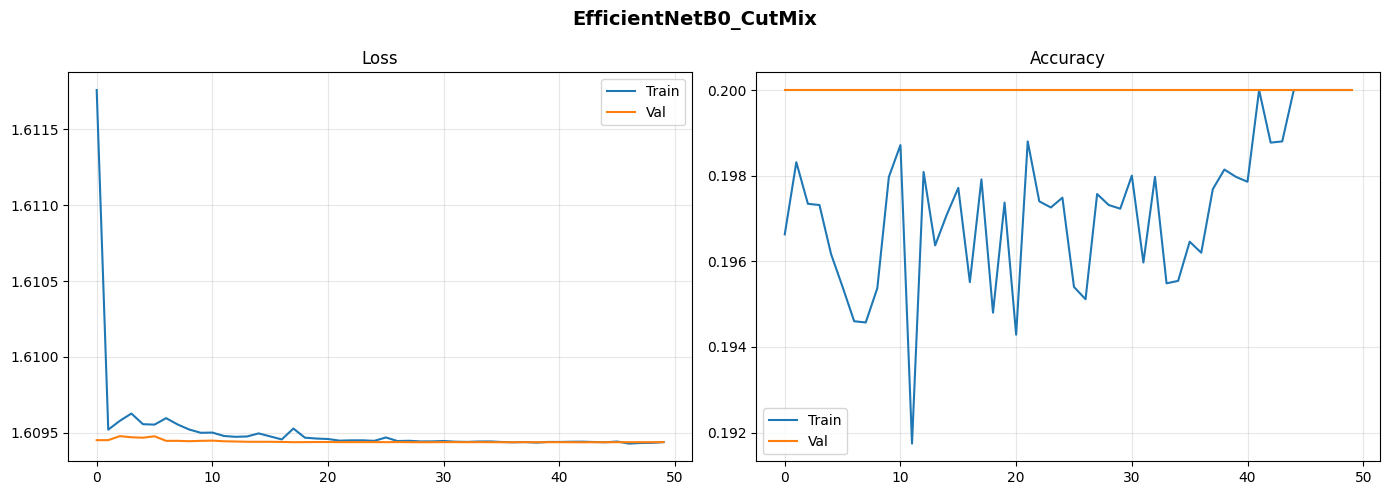

E0000 00:00:1773253675.526178   46448 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773253675.927375   46448 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773253677.495542   46448 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



EfficientNetB0_CutMix
  Accuracy : 20.00%  |  Top-3: 60.00%  |  Loss: 1.6094
              precision    recall  f1-score   support

  Cercospora     0.0000    0.0000    0.0000      1000
     Healthy     0.0000    0.0000    0.0000      1000
   Leaf_rust     0.2000    1.0000    0.3333      1000
       Miner     0.0000    0.0000    0.0000      1000
       Phoma     0.0000    0.0000    0.0000      1000

    accuracy                         0.2000      5000
   macro avg     0.0400    0.2000    0.0667      5000
weighted avg     0.0400    0.2000    0.0667      5000



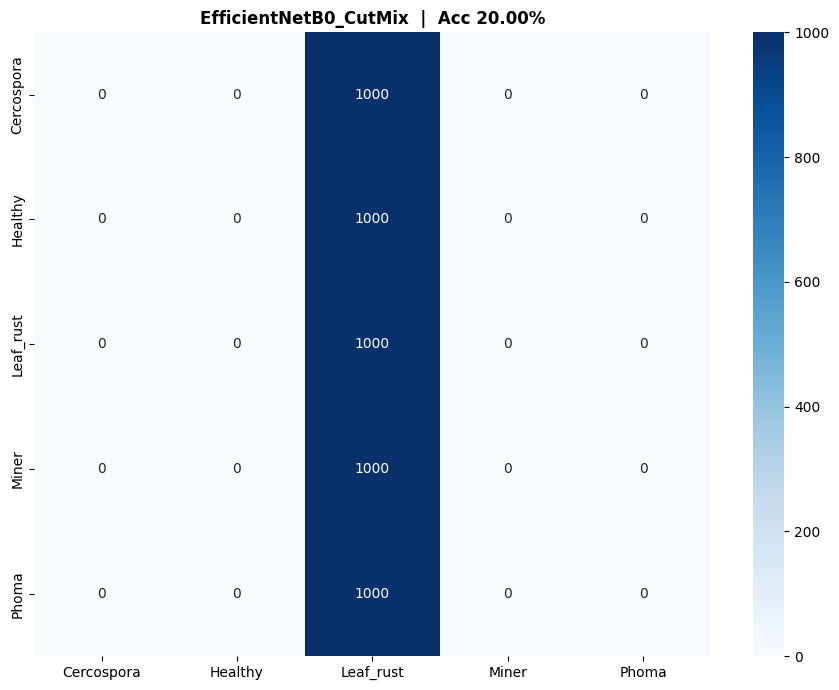

In [9]:
model_effb0 = create_efficientnet('B0')
print(f'Parâmetros: {model_effb0.count_params():,}')

hist_effb0 = model_effb0.fit(
    train_ds_cutmix, validation_data=val_ds, epochs=EPOCHS,
    callbacks=get_callbacks('EfficientNetB0_CutMix'), verbose=1
)
plot_history(hist_effb0, 'EfficientNetB0_CutMix')
res_effb0 = evaluate_model(model_effb0, 'EfficientNetB0_CutMix')

## Célula 10 – Treinar EfficientNetB1 + MixUp

27018416/27018416 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Parâmetros: 6,904,460
Epoch 1/50


E0000 00:00:1773253694.083339   46446 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1990 - loss: 1.6198 - top3_acc: 0.6048

E0000 00:00:1773253735.850574   46451 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.1990 - loss: 1.6198 - top3_acc: 0.6048

E0000 00:00:1773253752.183467   46446 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 68s 51ms/step - accuracy: 0.2001 - loss: 1.6125 - top3_acc: 0.6026 - val_accuracy: 0.2000 - val_loss: 1.6095 - val_top3_acc: 0.6000 - learning_rate: 0.0010
Epoch 2/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step - accuracy: 0.1972 - loss: 1.6096 - top3_acc: 0.5959 - val_accuracy: 0.2000 - val_loss: 1.6095 - val_top3_acc: 0.6000 - learning_rate: 0.0010
Epoch 3/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step - accuracy: 0.1991 - loss: 1.6096 - top3_acc: 0.5980 - val_accuracy: 0.2000 - val_loss: 1.6095 - val_top3_acc: 0.6000 - learning_rate: 0.0010
Epoch 4/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.1956 - loss: 1.6097 - top3_acc: 0.5935 - val_accuracy: 0.2000 - val_loss: 1.6095 - val_top3_acc: 0.6000 - learning_rate: 0.0010
Epoch 5/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.1972 - loss: 1.6096 - top3_acc: 0.5969 - val_accuracy: 0.2000 - val_loss: 1.6095 - val_top3_acc: 0.6000 - learning_rate: 0.0010
Epoch 6/50
1092/1094 

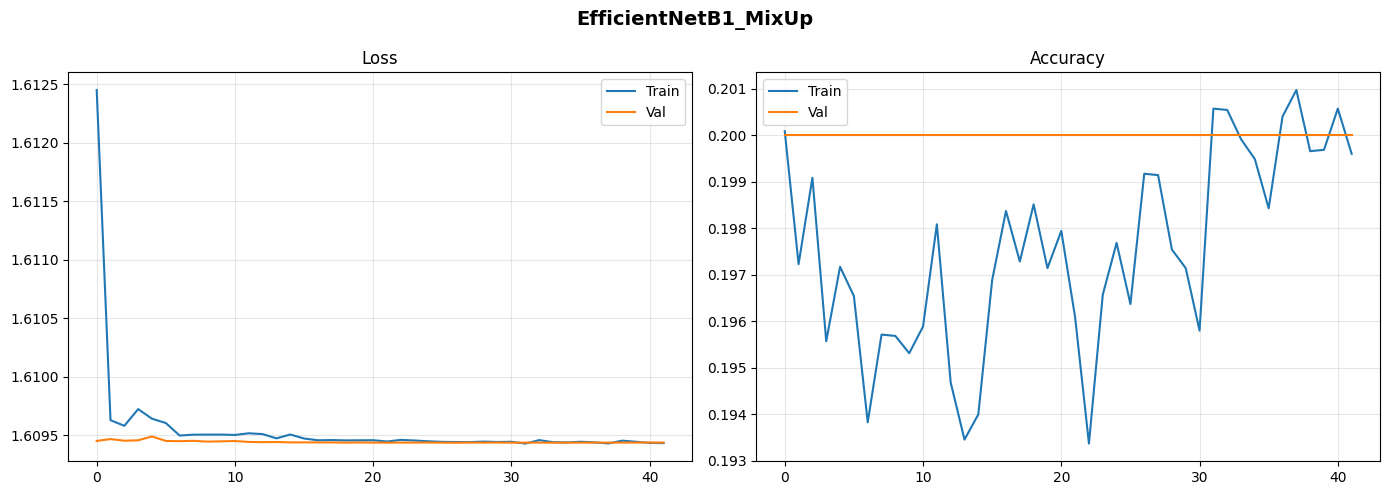

E0000 00:00:1773255466.723102   46448 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



EfficientNetB1_MixUp
  Accuracy : 20.00%  |  Top-3: 60.00%  |  Loss: 1.6094
              precision    recall  f1-score   support

  Cercospora     0.0000    0.0000    0.0000      1000
     Healthy     0.0000    0.0000    0.0000      1000
   Leaf_rust     0.2000    1.0000    0.3333      1000
       Miner     0.0000    0.0000    0.0000      1000
       Phoma     0.0000    0.0000    0.0000      1000

    accuracy                         0.2000      5000
   macro avg     0.0400    0.2000    0.0667      5000
weighted avg     0.0400    0.2000    0.0667      5000



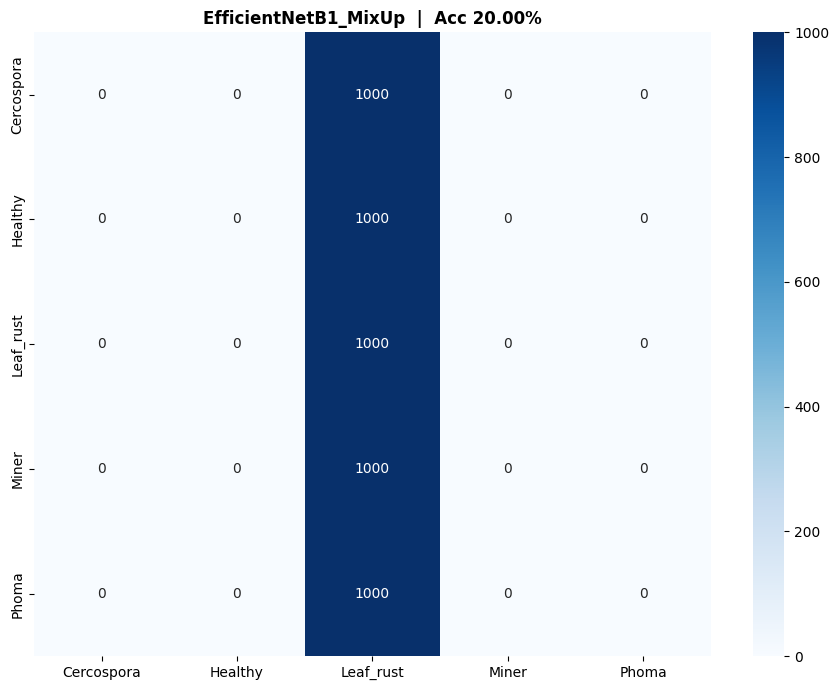

In [10]:
model_effb1 = create_efficientnet('B1')
print(f'Parâmetros: {model_effb1.count_params():,}')

hist_effb1 = model_effb1.fit(
    train_ds_mixup, validation_data=val_ds, epochs=EPOCHS,
    callbacks=get_callbacks('EfficientNetB1_MixUp'), verbose=1
)
plot_history(hist_effb1, 'EfficientNetB1_MixUp')
res_effb1 = evaluate_model(model_effb1, 'EfficientNetB1_MixUp')

## Célula 11 – Treinar MobileNetV3-Large

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Parâmetros: 3,243,653
Epoch 1/50


E0000 00:00:1773255625.327574   46446 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773255625.704579   46446 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1089/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2523 - loss: 1.6023 - top3_acc: 0.6905

E0000 00:00:1773255647.009374   46447 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773255647.499863   46447 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2525 - loss: 1.6020 - top3_acc: 0.6907

E0000 00:00:1773255657.277310   46446 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773255657.825752   46446 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1094/1094 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.2920 - loss: 1.5370 - top3_acc: 0.7458 - val_accuracy: 0.4912 - val_loss: 1.3921 - val_top3_acc: 0.8934 - learning_rate: 0.0010
Epoch 2/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.3648 - loss: 1.4243 - top3_acc: 0.8463 - val_accuracy: 0.4318 - val_loss: 1.2991 - val_top3_acc: 0.9350 - learning_rate: 0.0010
Epoch 3/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.4010 - loss: 1.3835 - top3_acc: 0.8668 - val_accuracy: 0.4790 - val_loss: 1.3115 - val_top3_acc: 0.8928 - learning_rate: 0.0010
Epoch 4/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.4273 - loss: 1.3516 - top3_acc: 0.8832 - val_accuracy: 0.6249 - val_loss: 1.2174 - val_top3_acc: 0.9481 - learning_rate: 0.0010
Epoch 5/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.4492 - loss: 1.3282 - top3_acc: 0.8913 - val_accuracy: 0.6809 - val_loss: 1.1923 - val_top3_acc: 0.9552 - learning_rate: 0.0010
Epoch 6/50
1094/1094 

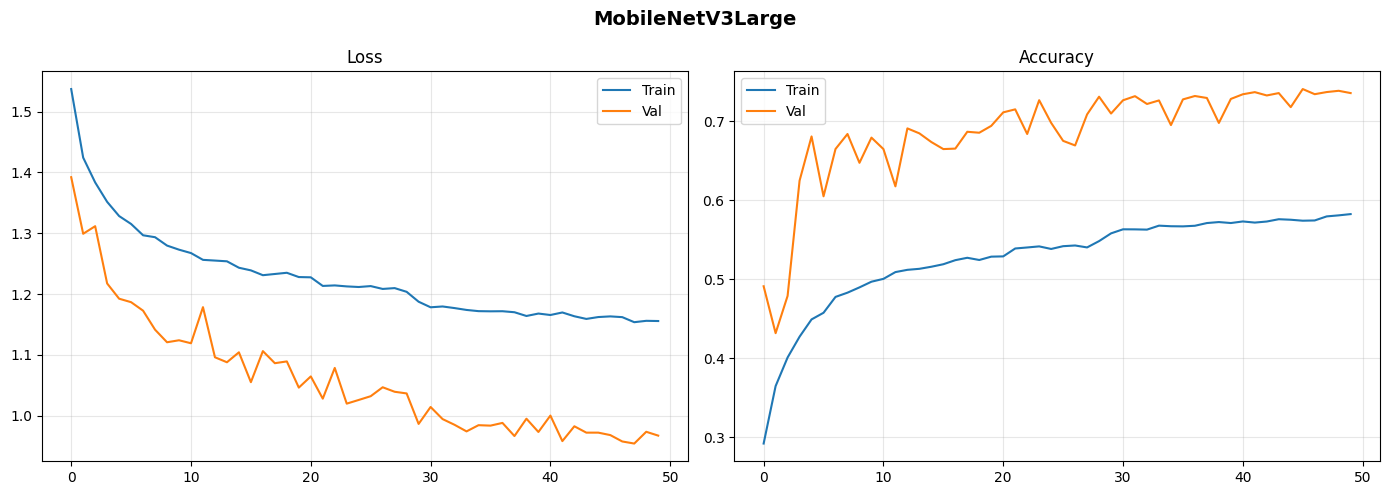

E0000 00:00:1773256524.708518   46449 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773256525.249861   46449 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



MobileNetV3Large
  Accuracy : 73.56%  |  Top-3: 97.48%  |  Loss: 0.9478
              precision    recall  f1-score   support

  Cercospora     0.5631    0.6510    0.6039      1000
     Healthy     0.8653    0.9380    0.9002      1000
   Leaf_rust     0.9725    0.9560    0.9642      1000
       Miner     0.5595    0.6540    0.6030      1000
       Phoma     0.7878    0.4790    0.5958      1000

    accuracy                         0.7356      5000
   macro avg     0.7497    0.7356    0.7334      5000
weighted avg     0.7497    0.7356    0.7334      5000



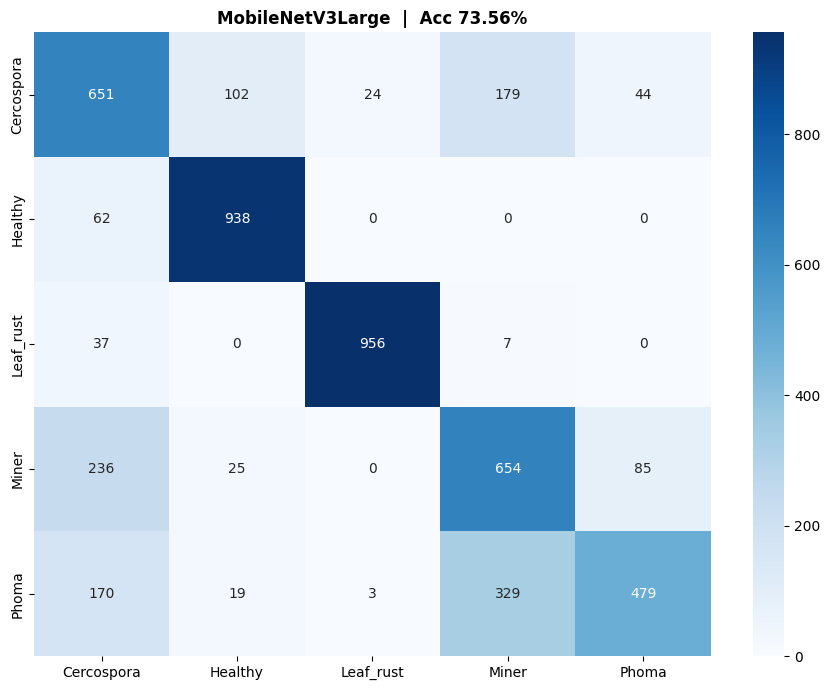

In [11]:
model_mobile = create_mobilenet()
print(f'Parâmetros: {model_mobile.count_params():,}')

hist_mobile = model_mobile.fit(
    train_ds, validation_data=val_ds, epochs=EPOCHS,
    callbacks=get_callbacks('MobileNetV3Large'), verbose=1
)
plot_history(hist_mobile, 'MobileNetV3Large')
res_mobile = evaluate_model(model_mobile, 'MobileNetV3Large')

## Célula 12 – Treinar Custom CNN + SE Attention

Parâmetros: 1,449,763
Epoch 1/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 122s 96ms/step - accuracy: 0.4069 - loss: 1.3985 - top3_acc: 0.8155 - val_accuracy: 0.6272 - val_loss: 1.0949 - val_top3_acc: 0.8700 - learning_rate: 0.0010
Epoch 2/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 86s 79ms/step - accuracy: 0.5177 - loss: 1.2587 - top3_acc: 0.8977 - val_accuracy: 0.8548 - val_loss: 0.7462 - val_top3_acc: 0.9929 - learning_rate: 0.0010
Epoch 3/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 88s 80ms/step - accuracy: 0.5804 - loss: 1.1822 - top3_acc: 0.9309 - val_accuracy: 0.8837 - val_loss: 0.7018 - val_top3_acc: 0.9882 - learning_rate: 0.0010
Epoch 4/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 86s 79ms/step - accuracy: 0.6206 - loss: 1.1354 - top3_acc: 0.9480 - val_accuracy: 0.9333 - val_loss: 0.6296 - val_top3_acc: 0.9953 - learning_rate: 0.0010
Epoch 5/50
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 87s 79ms/step - accuracy: 0.6472 - loss: 1.1085 - top3_acc: 0.9539 - val_accuracy: 0.9329 - val_loss: 0.6197 - val_top3_acc: 0.9987 - learning_

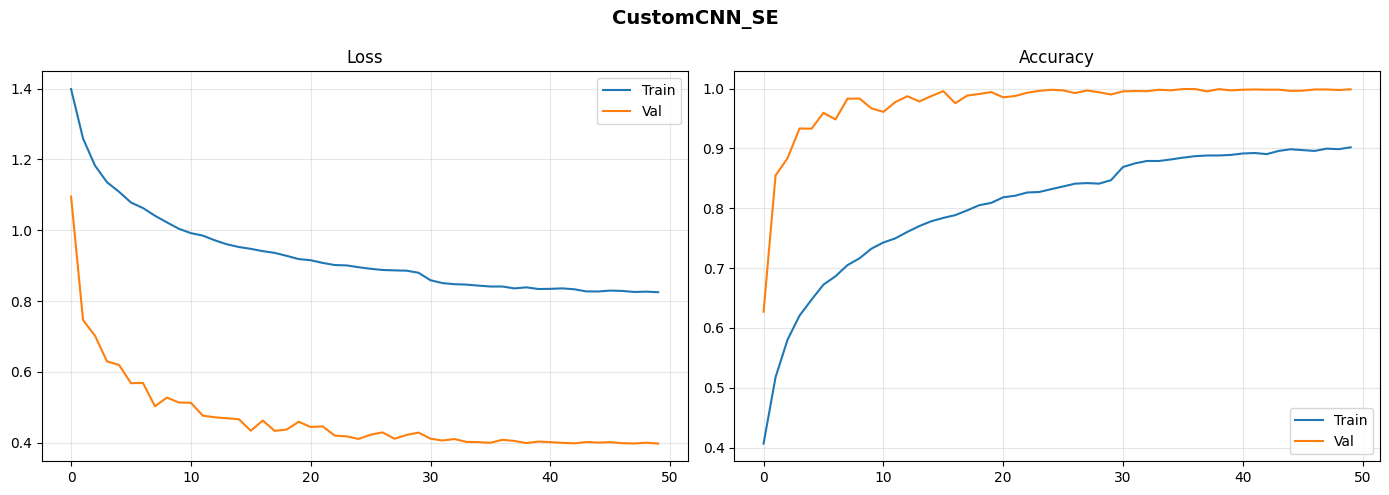


CustomCNN_SE
  Accuracy : 99.86%  |  Top-3: 100.00%  |  Loss: 0.3976
              precision    recall  f1-score   support

  Cercospora     0.9980    0.9980    0.9980      1000
     Healthy     1.0000    1.0000    1.0000      1000
   Leaf_rust     0.9980    1.0000    0.9990      1000
       Miner     0.9970    1.0000    0.9985      1000
       Phoma     1.0000    0.9950    0.9975      1000

    accuracy                         0.9986      5000
   macro avg     0.9986    0.9986    0.9986      5000
weighted avg     0.9986    0.9986    0.9986      5000



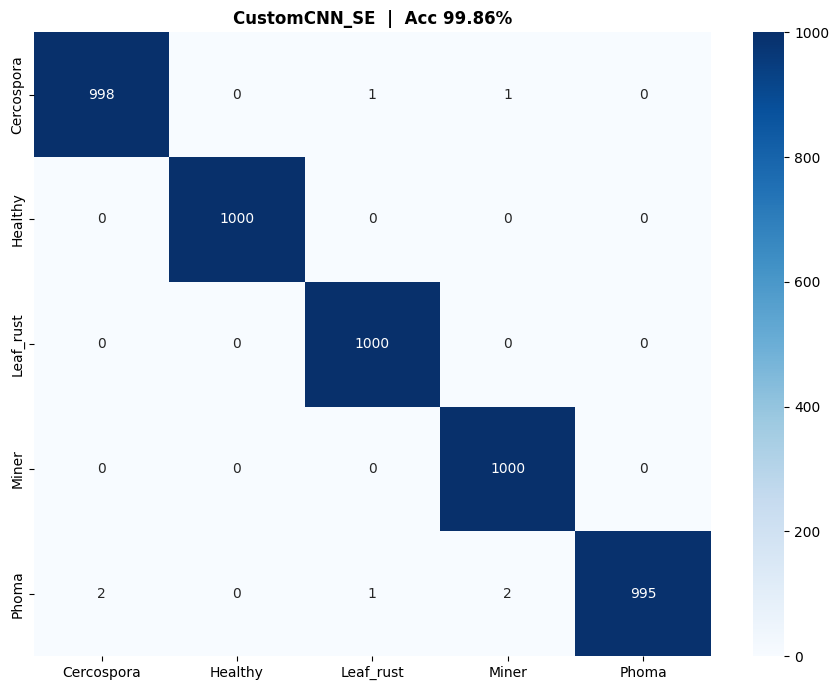

In [12]:
model_custom = create_custom_cnn_se()
print(f'Parâmetros: {model_custom.count_params():,}')

hist_custom = model_custom.fit(
    train_ds_cutmix, validation_data=val_ds, epochs=EPOCHS,
    callbacks=get_callbacks('CustomCNN_SE'), verbose=1
)
plot_history(hist_custom, 'CustomCNN_SE')
res_custom = evaluate_model(model_custom, 'CustomCNN_SE')

## Célula 13 – Fine-Tuning do Melhor Modelo

In [13]:
all_results = [res_effb0, res_effb1, res_mobile, res_custom]
best = max(all_results, key=lambda r: r['accuracy'])
print(f'Melhor modelo: {best["name"]}  ({best["accuracy"]*100:.2f}%)')

best_model = keras.models.load_model(MODELS_DIR / f'{best["name"]}_best.keras')

if 'EfficientNet' in best['name'] or 'MobileNet' in best['name']:
    print('Iniciando fine-tuning (descongelando últimas 30 camadas)...')
    backbone = best_model.layers[1]
    backbone.trainable = True
    for layer in backbone.layers[:-30]:
        layer.trainable = False
    best_model.compile(
        optimizer=optimizers.Adam(LEARNING_RATE / 10),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTHING),
        metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
    )
    ft_name = best['name'] + '_FineTuned'
    hist_ft = best_model.fit(
        train_ds_cutmix, validation_data=val_ds, epochs=20,
        callbacks=get_callbacks(ft_name, patience=10), verbose=1
    )
    plot_history(hist_ft, ft_name)
    res_ft = evaluate_model(best_model, ft_name)
    print(f'\nMelhoria: {best["accuracy"]*100:.2f}% → {res_ft["accuracy"]*100:.2f}%')
    all_results.append(res_ft)
else:
    print('Custom CNN já treinado from scratch, fine-tuning não aplicável.')

Melhor modelo: CustomCNN_SE  (99.86%)
Custom CNN já treinado from scratch, fine-tuning não aplicável.


## Célula 14 – Ensemble dos Top 3

Ensemble dos Top 3:
  CustomCNN_SE: 99.86%
  MobileNetV3Large: 73.56%
  EfficientNetB0_CutMix: 20.00%

🏆 Ensemble Accuracy: 99.92%


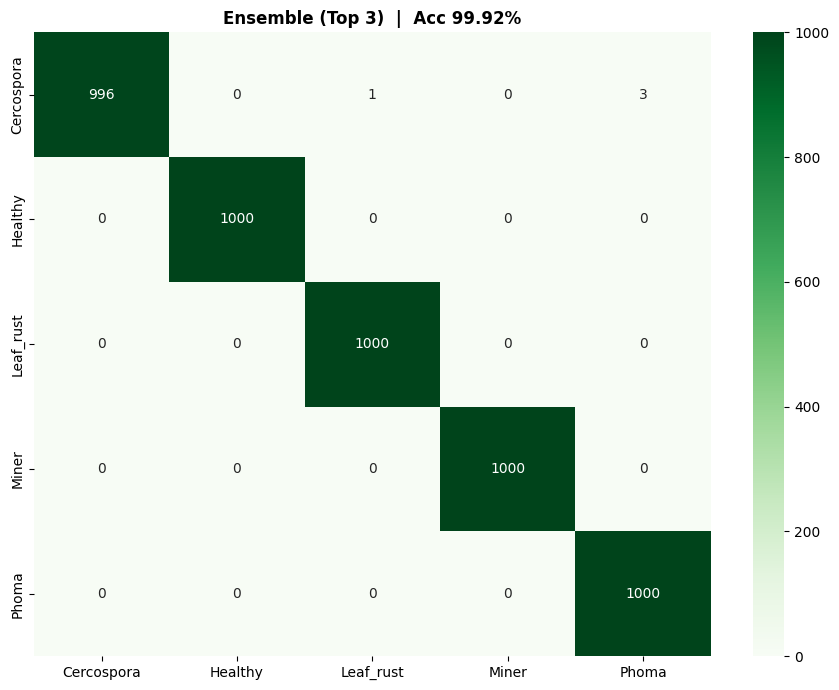

In [14]:
top3 = sorted(all_results, key=lambda r: r['accuracy'], reverse=True)[:3]
print('Ensemble dos Top 3:')
ensemble_models = []
for r in top3:
    m = keras.models.load_model(MODELS_DIR / f'{r["name"]}_best.keras')
    ensemble_models.append(m)
    print(f'  {r["name"]}: {r["accuracy"]*100:.2f}%')

# Predições
preds_list = [m.predict(test_ds, verbose=0) for m in ensemble_models]
ensemble_avg  = np.mean(preds_list, axis=0)
y_pred_ens    = np.argmax(ensemble_avg, axis=1)
y_true_ens    = np.concatenate([np.argmax(l.numpy(),axis=1) for _,l in test_ds])

from sklearn.metrics import accuracy_score
ens_acc = accuracy_score(y_true_ens, y_pred_ens)
print(f'\n🏆 Ensemble Accuracy: {ens_acc*100:.2f}%')

cm = confusion_matrix(y_true_ens, y_pred_ens)
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title(f'Ensemble (Top 3)  |  Acc {ens_acc*100:.2f}%', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'ensemble_cm.png', dpi=150, bbox_inches='tight')
plt.show()

## Célula 15 – Comparação Final

                Model Accuracy   Top-3   Loss
     Ensemble (Top 3)   99.92%       –      –
         CustomCNN_SE   99.86% 100.00% 0.3976
     MobileNetV3Large   73.56%  97.48% 0.9478
EfficientNetB0_CutMix   20.00%  60.00% 1.6094
 EfficientNetB1_MixUp   20.00%  60.00% 1.6094


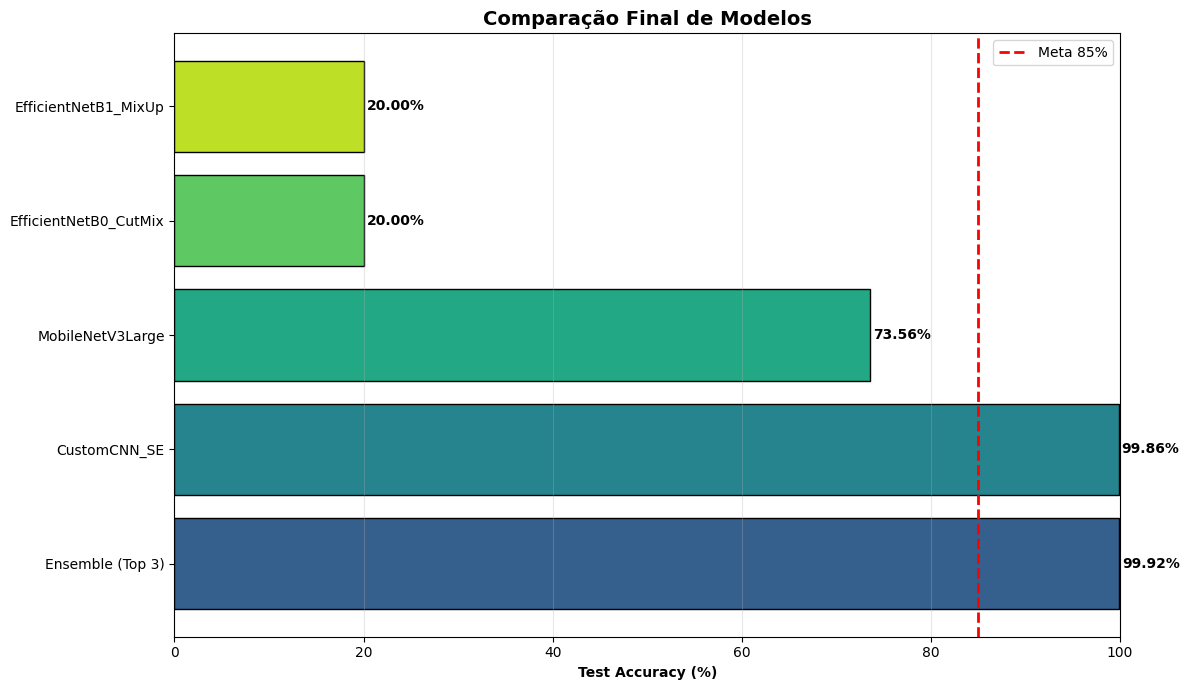


Melhor modelo: Ensemble (Top 3) — 99.92%


In [15]:
rows = [{'Model': r['name'], 'Accuracy': f"{r['accuracy']*100:.2f}%",
         'Top-3': f"{r['top3']*100:.2f}%", 'Loss': f"{r['loss']:.4f}"}
        for r in all_results]
rows.append({'Model':'Ensemble (Top 3)', 'Accuracy': f'{ens_acc*100:.2f}%',
             'Top-3':'–', 'Loss':'–'})

df = pd.DataFrame(rows)
df['_acc'] = df['Accuracy'].str.rstrip('%').astype(float)
df = df.sort_values('_acc', ascending=False).drop('_acc', axis=1)
print(df.to_string(index=False))
df.to_csv(OUTPUT_DIR/'final_comparison.csv', index=False)

# Gráfico
fig, ax = plt.subplots(figsize=(12, 7))
accs = [float(a.rstrip('%')) for a in df['Accuracy']]
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(df)))
bars = ax.barh(df['Model'], accs, color=colors, edgecolor='black')
for bar, acc in zip(bars, accs):
    ax.text(acc+0.3, bar.get_y()+bar.get_height()/2,
            f'{acc:.2f}%', va='center', fontweight='bold')
ax.axvline(85, color='red', linestyle='--', linewidth=2, label='Meta 85%')
ax.set_xlabel('Test Accuracy (%)', fontweight='bold')
ax.set_title('Comparação Final de Modelos', fontsize=14, fontweight='bold')
ax.set_xlim(0, 100); ax.legend(); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nMelhor modelo: {df.iloc[0]["Model"]} — {df.iloc[0]["Accuracy"]}')